In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Kaustubh Khisti
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:26<00:00, 91.4MB/s]


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import os
for dirname, _, filenames in os.walk('chest-xray-pneumonia'):
    for filename in filenames:
        if filename.endswith('.csv'):
            print(os.path.join(dirname, filename))

In [ ]:
import os

print("Directory structure of 'chest-xray-pneumonia':")
for dirname, _, _ in os.walk('chest-xray-pneumonia'):
    print(dirname)

Directory structure of 'chest-xray-pneumonia':
chest-xray-pneumonia
chest-xray-pneumonia/chest_xray
chest-xray-pneumonia/chest_xray/__MACOSX
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/NORMAL
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val/NORMAL
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train/NORMAL
chest-xray-pneumonia/chest_xray/test
chest-xray-pneumonia/chest_xray/test/PNEUMONIA
chest-xray-pneumonia/chest_xray/test/NORMAL
chest-xray-pneumonia/chest_xray/val
chest-xray-pneumonia/chest_xray/val/PNEUMONIA
chest-xray-pneumonia/chest_xray/v

The directory structure of the 'chest-xray-pneumonia' dataset is organized as follows:

- **chest-xray-pneumonia** (root directory)
  - **chest_xray**
    - **train**
      - **PNEUMONIA**: Contains training images of patients with pneumonia.
      - **NORMAL**: Contains training images of healthy patients.
    - **val**
      - **PNEUMONIA**: Contains validation images of patients with pneumonia.
      - **NORMAL**: Contains validation images of healthy patients.
    - **test**
      - **PNEUMONIA**: Contains test images of patients with pneumonia.
      - **NORMAL**: Contains test images of healthy patients.
  - There are also `__MACOSX` directories present, which are typically hidden system files generated by macOS and do not contain relevant image data for the study. These can be ignored for data analysis.

In [ ]:
image_counts = {}
base_dir = 'chest-xray-pneumonia/chest_xray/'

for split_name in ['train', 'val', 'test']:
    split_path = os.path.join(base_dir, split_name)
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_path = os.path.join(split_path, class_name)
        if os.path.exists(class_path) and os.path.isdir(class_path):
            # Count only files, exclude directories and hidden files (like .DS_Store)
            count = len([name for name in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, name)) and not name.startswith('.')])
            image_counts[f"{split_name}_{class_name}"] = count

print("Image counts per category:")
for category, count in image_counts.items():
    print(f"  {category}: {count} images")

Image counts per category:
  train_NORMAL: 1341 images
  train_PNEUMONIA: 3875 images
  val_NORMAL: 8 images
  val_PNEUMONIA: 8 images
  test_NORMAL: 234 images
  test_PNEUMONIA: 390 images


Displaying sample images from each category:


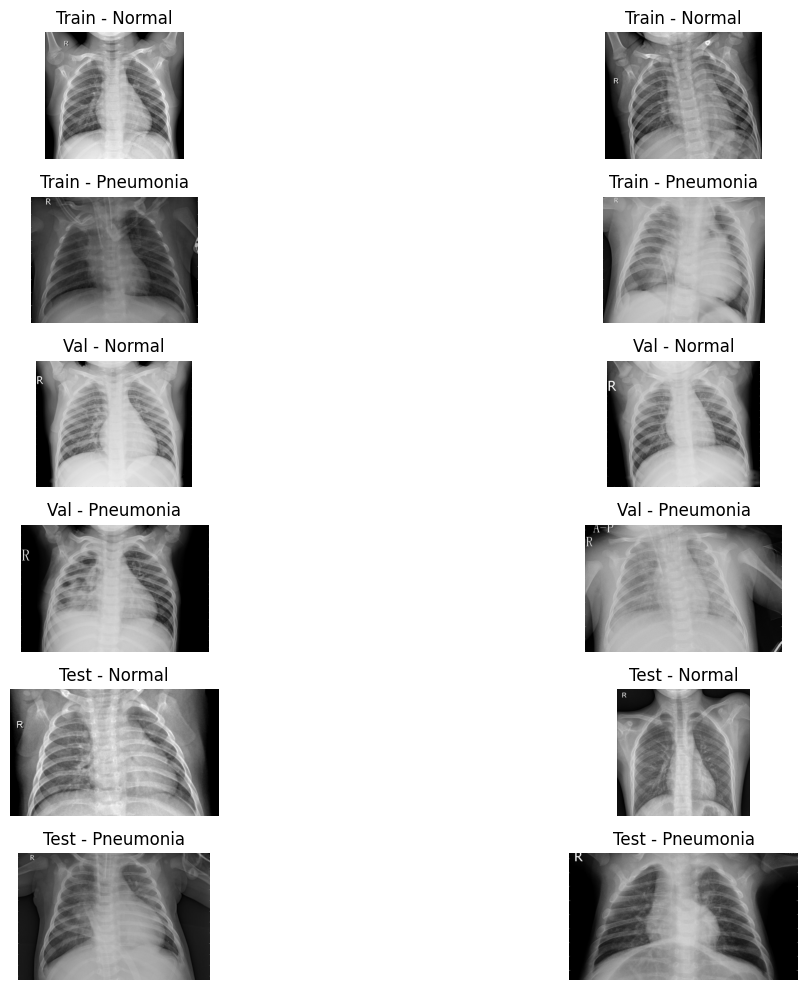

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def display_sample_images(base_dir, categories, num_samples_per_category=1):
    plt.figure(figsize=(15, 10))
    plot_index = 1

    for category_key in categories:
        split, class_name = category_key.split('_')
        category_path = os.path.join(base_dir, split, class_name)

        if os.path.exists(category_path) and os.path.isdir(category_path):
            image_files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f)) and not f.startswith('.')]

            if len(image_files) == 0:
                print(f"No image files found in {category_path}")
                continue

            # Select random samples, ensuring not to exceed available images
            samples_to_display = min(num_samples_per_category, len(image_files))
            sample_images = random.sample(image_files, samples_to_display)

            for i, img_file in enumerate(sample_images):
                img_path = os.path.join(category_path, img_file)
                plt.subplot(len(categories), num_samples_per_category, plot_index)
                img = mpimg.imread(img_path)
                plt.imshow(img, cmap='gray')
                plt.title(f"{split.capitalize()} - {class_name.capitalize()}")
                plt.axis('off')
                plot_index += 1
        else:
            print(f"Path not found: {category_path}")

    plt.tight_layout()
    plt.show()

# Base directory for the dataset images
base_image_dir = 'chest-xray-pneumonia/chest_xray/'

# Categories to display, using the keys from the image_counts dictionary
categories_to_display = list(image_counts.keys())

# Display 2 sample images per category
print("Displaying sample images from each category:")
display_sample_images(base_image_dir, categories_to_display, num_samples_per_category=2)


**Reasoning**:
The next logical step is to import the necessary libraries, define image transformations for training, validation, and test sets, and then create `ImageFolder` datasets and `DataLoader` objects to prepare the image data for model training, as outlined in the subtask instructions.



In [ ]:
import torch
from torchvision import transforms, datasets

# 1. Define image transformations
# Training transformations: Resize, ToTensor, Normalize
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation and Test transformations: Resize, ToTensor, Normalize
# No data augmentation for val/test sets
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Define base directory for the dataset
data_dir = 'chest-xray-pneumonia/chest_xray/'

# 3. Create ImageFolder datasets
train_dataset = datasets.ImageFolder(data_dir + 'train', transform=train_transforms)
val_dataset = datasets.ImageFolder(data_dir + 'val', transform=val_test_transforms)
test_dataset = datasets.ImageFolder(data_dir + 'test', transform=val_test_transforms)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# 4. Create DataLoader objects
batch_size = 32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")
print(f"Number of batches in test loader: {len(test_loader)}")


Training dataset size: 5216
Validation dataset size: 16
Test dataset size: 624
Number of batches in training loader: 163
Number of batches in validation loader: 1
Number of batches in test loader: 20


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # The input features for fc1 will depend on the output size of the last pooling layer.
        # For 224x224 input images: 224 -> 112 -> 56 -> 28
        # So, the feature map size before flattening is 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 1) # Output a single value for binary classification

    def forward(self, x):
        # First convolutional block
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Second convolutional block
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Third convolutional block
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # Flatten the output for the fully connected layers
        x = x.view(-1, 128 * 28 * 28)
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)


## Implement Training and Evaluation Loop

### Subtask:
Create a flexible training function that can accept different loss functions, optimizers, and regularization parameters. This function will also handle model training and validation, and return evaluation metrics.


**Reasoning**:
To implement the training and evaluation loop as described in the subtask, I need to define a Python function `train_model` that handles device setup, iterates through epochs, performs training and validation steps, calculates loss and accuracy, and stores these metrics. I will also include an accuracy calculation helper function.



In [ ]:
def calculate_accuracy(outputs, labels):
    predictions = torch.round(torch.sigmoid(outputs))
    correct = (predictions == labels).sum().item()
    return correct / labels.size(0)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, scheduler=None):
    # Move model to the specified device
    model.to(device)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Calculate training accuracy
            total_train += labels.size(0)
            correct_train += calculate_accuracy(outputs, labels) * labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        # Validation phase
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad(): # Disable gradient calculations during validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)

                # Calculate validation accuracy
                total_val += labels.size(0)
                correct_val += calculate_accuracy(outputs, labels) * labels.size(0)

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

        if scheduler:
            scheduler.step(epoch_val_loss) # Update learning rate if scheduler is provided

    print("Training complete!")
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Define experiment configurations
experiment_configs = [
    {
        'name': 'Experiment 1: Adam with BCE (LR=0.001)',
        'loss_function': nn.BCEWithLogitsLoss(),
        'optimizer': (optim.Adam, {'lr': 0.001})
    },
    {
        'name': 'Experiment 2: Adam with BCE (LR=0.0005)',
        'loss_function': nn.BCEWithLogitsLoss(),
        'optimizer': (optim.Adam, {'lr': 0.0005})
    },
    {
        'name': 'Experiment 3: SGD with BCE (LR=0.01, Momentum=0.9)',
        'loss_function': nn.BCEWithLogitsLoss(),
        'optimizer': (optim.SGD, {'lr': 0.01, 'momentum': 0.9})
    }
]

print("Defined experiment configurations:")
for config in experiment_configs:
    print(f"- {config['name']}: Loss = {type(config['loss_function']).__name__}, Optimizer = {config['optimizer'][0].__name__}, Params = {config['optimizer'][1]}")

Defined experiment configurations:
- Experiment 1: Adam with BCE (LR=0.001): Loss = BCEWithLogitsLoss, Optimizer = Adam, Params = {'lr': 0.001}
- Experiment 2: Adam with BCE (LR=0.0005): Loss = BCEWithLogitsLoss, Optimizer = Adam, Params = {'lr': 0.0005}
- Experiment 3: SGD with BCE (LR=0.01, Momentum=0.9): Loss = BCEWithLogitsLoss, Optimizer = SGD, Params = {'lr': 0.01, 'momentum': 0.9}


In [ ]:
all_experiment_results = []
num_epochs = 5 # Reduced for quicker execution for demonstration purposes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

for config in experiment_configs:
    print(f"\n--- Starting {config['name']} ---")

    # Initialize a new model for each experiment
    model = CNN()
    model.to(device)

    # Setup loss function and optimizer
    criterion = config['loss_function']
    optimizer_class, optimizer_params = config['optimizer']
    optimizer = optimizer_class(model.parameters(), **optimizer_params)

    # Train the model
    metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

    # Store results
    experiment_result = {
        'name': config['name'],
        'metrics': metrics
    }
    all_experiment_results.append(experiment_result)

print("\nAll experiments finished. Results:")
for result in all_experiment_results:
    print(f"\nExperiment: {result['name']}")
    print(f"  Train Losses: {[f'{l:.4f}' for l in result['metrics']['train_losses']]}")
    print(f"  Val Losses: {[f'{l:.4f}' for l in result['metrics']['val_losses']]}")
    print(f"  Train Accuracies: {[f'{a:.4f}' for a in result['metrics']['train_accuracies']]}")
    print(f"  Val Accuracies: {[f'{a:.4f}' for a in result['metrics']['val_accuracies']]}")

Using device: cuda

--- Starting Experiment 1: Adam with BCE (LR=0.001) ---
Epoch 1/5 - Train Loss: 1.0059, Train Acc: 0.9302 | Val Loss: 1.1164, Val Acc: 0.8750
Epoch 2/5 - Train Loss: 0.2154, Train Acc: 0.9574 | Val Loss: 0.0189, Val Acc: 1.0000
Epoch 3/5 - Train Loss: 0.0728, Train Acc: 0.9774 | Val Loss: 0.3948, Val Acc: 0.8125
Epoch 4/5 - Train Loss: 0.0384, Train Acc: 0.9858 | Val Loss: 0.2087, Val Acc: 0.8125
Epoch 5/5 - Train Loss: 0.0292, Train Acc: 0.9885 | Val Loss: 0.5672, Val Acc: 0.7500
Training complete!

--- Starting Experiment 2: Adam with BCE (LR=0.0005) ---
Epoch 1/5 - Train Loss: 0.7211, Train Acc: 0.9327 | Val Loss: 1.0939, Val Acc: 0.6875
Epoch 2/5 - Train Loss: 0.1645, Train Acc: 0.9609 | Val Loss: 1.1096, Val Acc: 0.6875
Epoch 3/5 - Train Loss: 0.0832, Train Acc: 0.9768 | Val Loss: 0.3548, Val Acc: 0.8750
Epoch 4/5 - Train Loss: 0.0468, Train Acc: 0.9845 | Val Loss: 0.3678, Val Acc: 0.8750
Epoch 5/5 - Train Loss: 0.0392, Train Acc: 0.9881 | Val Loss: 0.2816, Val

In [ ]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

def evaluate_model_metrics(model, data_loader, device):
    model.eval() # Set model to evaluation mode
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float().view(-1, 1)

            outputs = model(inputs)
            predictions = torch.round(torch.sigmoid(outputs))

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)

    # Optional: Confusion Matrix
    # cm = confusion_matrix(all_labels, all_predictions)

    return precision, recall, f1

In [ ]:
evaluation_results = []
num_epochs_eval = 5 # Using the same number of epochs as before

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

for config in experiment_configs:
    print(f"\n--- Re-training and Evaluating {config['name']} ---")

    # Initialize a new model for each experiment
    model_eval = CNN()
    model_eval.to(device)

    # Setup loss function and optimizer
    criterion_eval = config['loss_function']
    optimizer_class_eval, optimizer_params_eval = config['optimizer']
    optimizer_eval = optimizer_class_eval(model_eval.parameters(), **optimizer_params_eval)

    # Train the model
    # The train_model function modifies model_eval in-place
    train_model(model_eval, train_loader, val_loader, criterion_eval, optimizer_eval, num_epochs_eval, device)

    # Evaluate the trained model on the test set
    precision, recall, f1 = evaluate_model_metrics(model_eval, test_loader, device)

    # Store evaluation results
    eval_result = {
        'name': config['name'],
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    evaluation_results.append(eval_result)

print("\nAll evaluations complete. Results on the Test Set:")
for result in evaluation_results:
    print(f"\nExperiment: {result['name']}")
    print(f"  Precision: {result['precision']:.4f}")
    print(f"  Recall: {result['recall']:.4f}")
    print(f"  F1-Score: {result['f1_score']:.4f}")

Using device: cuda

--- Re-training and Evaluating Experiment 1: Adam with BCE (LR=0.001) ---
Epoch 1/5 - Train Loss: 1.3067, Train Acc: 0.9227 | Val Loss: 1.7698, Val Acc: 0.5625
Epoch 2/5 - Train Loss: 0.0816, Train Acc: 0.9701 | Val Loss: 0.8682, Val Acc: 0.6875
Epoch 3/5 - Train Loss: 0.0661, Train Acc: 0.9753 | Val Loss: 0.3724, Val Acc: 0.8750
Epoch 4/5 - Train Loss: 0.0411, Train Acc: 0.9856 | Val Loss: 0.0473, Val Acc: 1.0000
Epoch 5/5 - Train Loss: 0.0438, Train Acc: 0.9833 | Val Loss: 0.1070, Val Acc: 0.9375
Training complete!

--- Re-training and Evaluating Experiment 2: Adam with BCE (LR=0.0005) ---
Epoch 1/5 - Train Loss: 0.7726, Train Acc: 0.9365 | Val Loss: 0.1547, Val Acc: 0.8750
Epoch 2/5 - Train Loss: 0.2111, Train Acc: 0.9682 | Val Loss: 0.5089, Val Acc: 0.8750
Epoch 3/5 - Train Loss: 0.1216, Train Acc: 0.9789 | Val Loss: 0.0203, Val Acc: 1.0000
Epoch 4/5 - Train Loss: 0.0730, Train Acc: 0.9837 | Val Loss: 0.6747, Val Acc: 0.7500
Epoch 5/5 - Train Loss: 0.0514, Train

### Visualizing Test Set Evaluation Metrics (Precision, Recall, F1-Score)

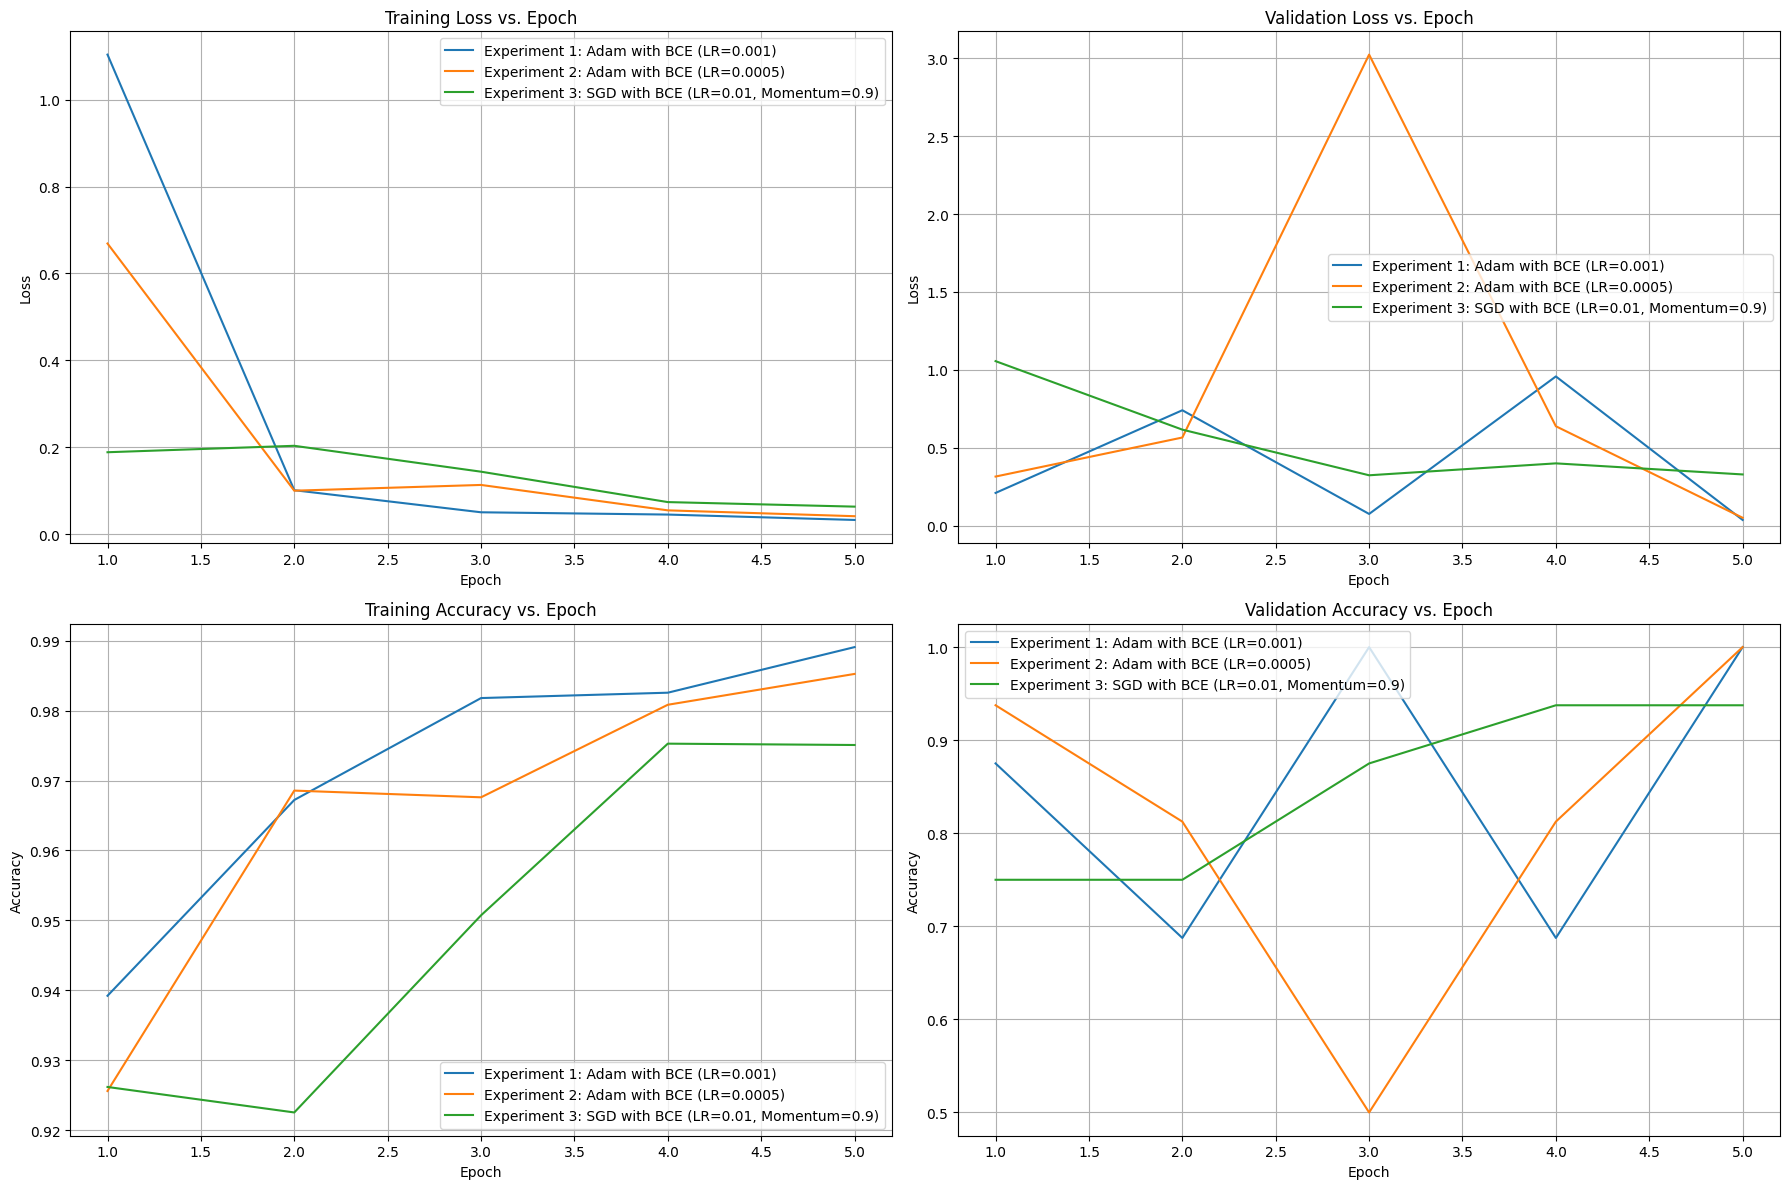

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
num_epochs_per_experiment = len(all_experiment_results[0]['metrics']['train_losses'])
epochs = range(1, num_epochs_per_experiment + 1)

# Create a figure with 2x2 subplots
plt.figure(figsize=(18, 12))

# Plot 1: Training Loss
plt.subplot(2, 2, 1)
for result in all_experiment_results:
    plt.plot(epochs, [float(l) for l in result['metrics']['train_losses']], label=result['name'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epoch')
plt.legend()
plt.grid(True)

# Plot 2: Validation Loss
plt.subplot(2, 2, 2)
for result in all_experiment_results:
    plt.plot(epochs, [float(l) for l in result['metrics']['val_losses']], label=result['name'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)

# Plot 3: Training Accuracy
plt.subplot(2, 2, 3)
for result in all_experiment_results:
    plt.plot(epochs, [float(a) for a in result['metrics']['train_accuracies']], label=result['name'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs. Epoch')
plt.legend()
plt.grid(True)

# Plot 4: Validation Accuracy
plt.subplot(2, 2, 4)
for result in all_experiment_results:
    plt.plot(epochs, [float(a) for a in result['metrics']['val_accuracies']], label=result['name'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs. Epoch')
plt.legend()
plt.grid(True)

# Adjust layout and display plots
plt.tight_layout()
plt.show()
